### 6. 梯度下降(算法) Gradient Descent 10-15
前面已经知道：

- 模型：$f_{w,b}(x)=wx+b$
- (策略)成本函数：$ J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})^2 $
- (算法)梯度下降是目标：找到让 $J(w,b)$ 最小的 $w,b$
---
#### 1. 梯度下降

梯度下降的作用：
> 不断调整 $w,b$，让成本函数 $J(w,b)$ 变小。

可以理解成：

- 现在站在山坡上，360度旋转，为了下山，应该朝那个方向迈步
- 找到下坡方向
- 往下坡方向走一步
- 重复很多次
- 最后接近最低点

最低点就是：$J(w,b)$ 最小的位置。

---

#### 2. 实现梯度下降 

梯度下降会不断更新参数：

| 参数 | 更新公式 |
|---|---|
| $w$ | $w = w - \alpha \frac{\partial J(w,b)}{\partial w}$ |
| $b$ | $b = b - \alpha \frac{\partial J(w,b)}{\partial b}$ |

其中：
- = 是给w赋值
- $\alpha$：学习率（learning rate）通常是0-1之间的小正数，控制下坡时步子的大小
- 模型：$ f_{w,b}(x^{(i)})=wx^{(i)}+b $
- 成本函数：$ J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})^2 $
- $ \frac{\partial J(w,b)}{\partial w}$：告诉 $w$ 应该怎么变，求导后：$\frac{1}{m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})*x^{(i)}$
- $ \frac{\partial J(w,b)}{\partial b}$：告诉 $b$ 应该怎么变，求导后：$\frac{1}{m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})$
- 
>重点： $w$ 和 $b$ 要同时更新。

---

#### 3. 梯度下降直觉 
> 导数可以理解成：当前点的斜率。

用开口向上的抛物线举例（U）假设b为0

如果某个点在极小值的右侧，则(导数)斜率是正的：w = w-求导后的结果，最终会得到一个更小的w

- 在图上表示参数应该往左走，减小w的值，让 代价cost J(w)变小

如果在极小值的左侧，则(导数)斜率是负的：w = w-求导后的结果，最终会得到一个更大的w

- 在图上表示参数应该往右走，增加w的值，让代价cost J(w)变小

所以梯度下降会根据斜率判断：
> 参数应该往哪个方向调整。
> 
> 核心：斜率决定方向，学习率决定步子大小。

---

#### 4. 学习率

学习率 $\alpha$ 控制每次走多大一步。

如果 $\alpha$ 太小：每一步很小，下降很慢，需要训练很多次

如果 $\alpha$ 太大：每一步太大，可能跨过最低点，使cost 可能越来越大

所以：

> 学习率不能太大，也不能太小。
> 
> 当接近局部最小值时，导数会越来越小，梯度下降会采取更小的步骤(学习率a)，也就是学习率逐渐减小
---

#### 5. 线性回归的梯度下降

当使用线性回归的平方误差成本函数后，成本函数 $J(w,b)$ 不会有多个局部最小值，是一个凸函数。(从上往下看)
>也就是像一个碗一样，只有一个最低点。

所以线性回归中使用梯度下降时：

- 不用担心卡在很多局部最低点
- 目标就是找到这个碗底
- 碗底对应的 $w,b$ 就是最优参数
>核心： 对线性回归来说，梯度下降最终会朝着全局最低点前进。

---


#### 7. 梯度下降总结

本部分需要记住：

1. 成本函数 $J(w,b)$ 用来衡量模型好不好
2. 梯度下降用来自动调整 $w,b$
3. 目标是让 $J(w,b)$ 越来越小
4. 学习率 $\alpha$ 决定每次走多大一步
5. 线性回归的成本函数像一个碗，最低点就是最优参数

最核心一句话：

> 梯度下降就是不断更新 $w,b$，让成本函数 $J(w,b)$ 一步一步变小。

#### 8. 代码
代码流程：
1. 导入成本函数作业需要的工具
2. 准备训练数据
3. 实现成本函数 compute_cost
4. 线性回归模型的梯度计算与可视化

In [1]:
"""
1. 导入成本函数作业需要的工具
2. 准备训练数据
3. 实现成本函数 compute_cost
"""

#1. 导包
import numpy as np
import matplotlib.pyplot as plt
import math, copy #调用数学常用函数，复制工具
from lab_utils_uni import plt_house_x, plt_contour_wgrad, plt_divergence, plt_gradients

# 2. 准备训练数据
x_train = np.array([1.0, 2.0])   
y_train = np.array([300.0, 500.0])  

#3. 实现成本函数 compute_cost
def compute_cost(x, y, w, b):
   
    m = x.shape[0] 
    cost = 0
    
    for i in range(m):
        f_wb = w * x[i] + b
        cost = cost + (f_wb - y[i])**2
    total_cost = 1 / (2 * m) * cost

    return total_cost

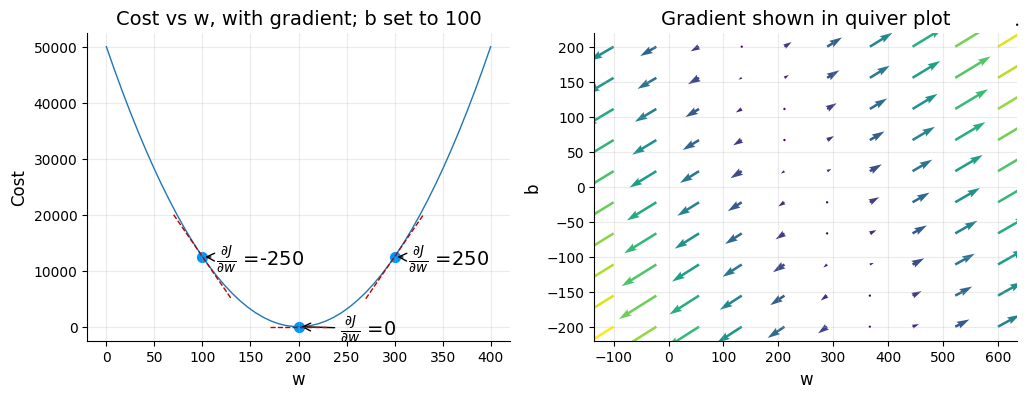

In [3]:
""" 
4. 梯度计算与可视化
   compute_gradient来算:损失函数J(w,b)对 w 和 b 的梯度（导数，斜率）

    两个梯度公式:
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = f_wb - y[i]
"""

def compute_gradient(x, y, w, b): 

    m = x.shape[0]  

    # 初始化梯度为 0 
    dj_dw = 0
    dj_db = 0
    
    for i in range(m):  
        f_wb = w * x[i] + b  # 模型预测值
        dj_dw_i = (f_wb - y[i]) * x[i] # 第 i 个样本对 w 的导数
        dj_db_i = f_wb - y[i]          # 第 i 个样本对 b 的导数
        dj_db += dj_db_i     # 累加 b 的梯度
        dj_dw += dj_dw_i     # 累加 w 的梯度

    # 最后求平均（除以 m）
    dj_dw = dj_dw / m 
    dj_db = dj_db / m 
        
    return dj_dw, dj_db

plt_gradients(x_train,y_train, compute_cost, compute_gradient)
plt.show()

In [4]:

def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function): 

    
    w = copy.deepcopy(w_in) # avoid modifying global w_in
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    p_history = []
    b = b_in
    w = w_in
    
    for i in range(num_iters):
        # Calculate the gradient and update the parameters using gradient_function
        dj_dw, dj_db = gradient_function(x, y, w , b)     

        # Update Parameters using equation (3) above
        b = b - alpha * dj_db                            
        w = w - alpha * dj_dw                            

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(x, y, w , b))
            p_history.append([w,b])
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")
 
    return w, b, J_history, p_history #return w and J,w history for graphing



# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-2
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")


Iteration    0: Cost 7.93e+04  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  6.500e+00, b: 4.00000e+00
Iteration 1000: Cost 3.41e+00  dj_dw: -3.712e-01, dj_db:  6.007e-01   w:  1.949e+02, b: 1.08228e+02
Iteration 2000: Cost 7.93e-01  dj_dw: -1.789e-01, dj_db:  2.895e-01   w:  1.975e+02, b: 1.03966e+02
Iteration 3000: Cost 1.84e-01  dj_dw: -8.625e-02, dj_db:  1.396e-01   w:  1.988e+02, b: 1.01912e+02
Iteration 4000: Cost 4.28e-02  dj_dw: -4.158e-02, dj_db:  6.727e-02   w:  1.994e+02, b: 1.00922e+02
Iteration 5000: Cost 9.95e-03  dj_dw: -2.004e-02, dj_db:  3.243e-02   w:  1.997e+02, b: 1.00444e+02
Iteration 6000: Cost 2.31e-03  dj_dw: -9.660e-03, dj_db:  1.563e-02   w:  1.999e+02, b: 1.00214e+02
Iteration 7000: Cost 5.37e-04  dj_dw: -4.657e-03, dj_db:  7.535e-03   w:  1.999e+02, b: 1.00103e+02
Iteration 8000: Cost 1.25e-04  dj_dw: -2.245e-03, dj_db:  3.632e-03   w:  2.000e+02, b: 1.00050e+02
Iteration 9000: Cost 2.90e-05  dj_dw: -1.082e-03, dj_db:  1.751e-03   w:  2.000e+02, b: 1.00024e+02
